## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
import json

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Load & Eksplorasi Data

In [2]:
df = pd.read_csv('dataset/sayur_buah_bersih.csv')

print(df.shape)
df.head()

(3723, 6)


,nama_item,jenis_item,lokasi_penyimpanan,hari_sejak_pembelian,sisa_hari,label
0,Mangga,Buah,Pembeku,0,33,Matang
1,Timun,Sayur,Suhu Ruang,2,1,Busuk
2,Tomat,Sayur,Pendingin,0,2,Busuk
3,Apel,Buah,Suhu Ruang,4,16,Mentah
4,Tomat,Sayur,Suhu Ruang,1,0,Busuk


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3723 entries, 0 to 3722
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   nama_item             3723 non-null   object
 1   jenis_item            3723 non-null   object
 2   lokasi_penyimpanan    3723 non-null   object
 3   hari_sejak_pembelian  3723 non-null   int64 
 4   sisa_hari             3723 non-null   int64 
 5   label                 3723 non-null   object
dtypes: int64(2), object(4)
memory usage: 174.6+ KB


In [4]:
df.isnull().sum()

nama_item               0
jenis_item              0
lokasi_penyimpanan      0
hari_sejak_pembelian    0
sisa_hari               0
label                   0
dtype: int64

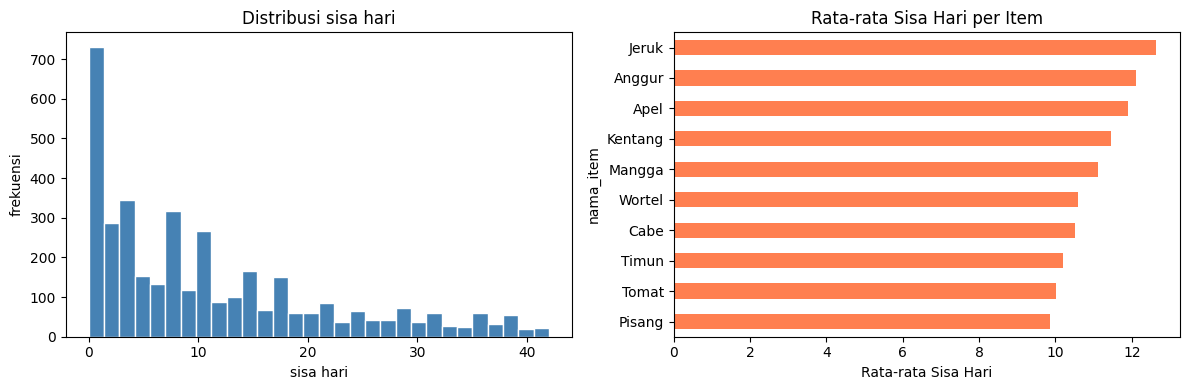

In [5]:
# Distribusi target

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['sisa_hari'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi sisa hari')
axes[0].set_xlabel('sisa hari')
axes[0].set_ylabel('frekuensi')

df.groupby('nama_item')['sisa_hari'].mean().sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Rata-rata Sisa Hari per Item')
axes[1].set_xlabel('Rata-rata Sisa Hari')

plt.tight_layout()
plt.show()

## Oversampling

In [6]:
TARGET_PER_LABEL = 900

df_balanced = []
for label in df['label'].unique():
    df_label = df[df['label'] == label]
    if len(df_label) < TARGET_PER_LABEL:
        # Oversample: duplikasi baris yang ada
        df_label = resample(df_label, replace=True,
                            n_samples=TARGET_PER_LABEL, random_state=SEED)
    else:
        # Undersample: kurangi yang terlalu banyak
        df_label = resample(df_label, replace=False,
                            n_samples=TARGET_PER_LABEL, random_state=SEED)
    df_balanced.append(df_label)

df = pd.concat(df_balanced).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"\nDistribusi label setelah balancing:")
print(df['label'].value_counts())
print(f"\nTotal baris: {len(df)}")


Distribusi label setelah balancing:
label
Mentah            900
Segar             900
Terlalu Matang    900
Matang            900
Busuk             900
Name: count, dtype: int64

Total baris: 4500


## Preprocessing

In [7]:
CAT_COLS = ['nama_item', 'jenis_item', 'lokasi_penyimpanan', 'label']
NUM_COLS = ['hari_sejak_pembelian']
TARGET   = 'sisa_hari'

FEATURE_COLS = CAT_COLS + NUM_COLS

In [8]:
X = df[FEATURE_COLS].copy()
y = df[TARGET].values.astype(np.int32)

print('Fitur:', FEATURE_COLS)
print('Shape X:', X.shape, '| Shape y:', y.shape)

Fitur: ['nama_item', 'jenis_item', 'lokasi_penyimpanan', 'label', 'hari_sejak_pembelian']
Shape X: (4500, 5) | Shape y: (4500,)


In [9]:
encoders = {}

for col in CAT_COLS:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le
    print(f'{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}')

nama_item: {'Anggur': 0, 'Apel': 1, 'Cabe': 2, 'Jeruk': 3, 'Kentang': 4, 'Mangga': 5, 'Pisang': 6, 'Timun': 7, 'Tomat': 8, 'Wortel': 9}
jenis_item: {'Buah': 0, 'Sayur': 1}
lokasi_penyimpanan: {'Pembeku': 0, 'Pendingin': 1, 'Suhu Ruang': 2}
label: {'Busuk': 0, 'Matang': 1, 'Mentah': 2, 'Segar': 3, 'Terlalu Matang': 4}


In [10]:
# Scaler
scaler = StandardScaler()
X[NUM_COLS] = scaler.fit_transform(X[NUM_COLS])

X_array = X.values.astype(np.float32)
print('Sample X setelah preprocessing:')
print(X_array[:3])

Sample X setelah preprocessing:
[[ 1.          0.          2.          2.          0.4428212 ]
 [ 9.          1.          1.          3.          1.5545062 ]
 [ 0.          0.          0.          4.         -0.66886383]]


## Weighting

In [11]:
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=df['label']   # berdasarkan label, bukan nilai sisa_hari
)

print(f"Weight range: {sample_weights.min():.4f} – {sample_weights.max():.4f}")



Weight range: 1.0000 – 1.0000


## Split Data

In [12]:
X_train, X_temp, y_train, y_temp, sw_train, sw_temp = train_test_split(
    X_array, y, sample_weights, test_size=0.30, random_state=SEED
)
X_val, X_test, y_val, y_test, sw_val, sw_test = train_test_split(
    X_temp, y_temp, sw_temp, test_size=0.50, random_state=SEED
)

print(f"Train : {X_train.shape[0]} sampel")
print(f"Val   : {X_val.shape[0]} sampel")
print(f"Test  : {X_test.shape[0]} sampel")

Train : 3150 sampel
Val   : 675 sampel
Test  : 675 sampel


## Build Model

In [13]:
def build_model(input_dim: int, learning_rate: float = 1e-3) -> keras.Model:
    """
    MLP untuk regresi sisa hari.
    
    Arsitektur:
      - 3 hidden layer dengan ukuran bertahap mengecil
      - BatchNormalization: menstabilkan training
      - Dropout: mencegah overfitting (data ~4400 baris)
      - L2 regularization: tambahan pengaman overfitting
      - Output: 1 neuron linear (regresi, prediksi float)
    """
    inputs = keras.Input(shape=(input_dim,), name='input_fitur')

    # Layer 1
    x = layers.Dense(
        128,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense_1'
    )(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.3, name='drop_1')(x)

    # Layer 2
    x = layers.Dense(
        64,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense_2'
    )(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.2, name='drop_2')(x)

    # Layer 3
    x = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=regularizers.l2(1e-4),
        name='dense_3'
    )(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.Dropout(0.1, name='drop_3')(x)

    # Output layer — linear, tidak ada aktivasi (regresi)
    outputs = layers.Dense(1, activation='linear', name='output')(x)

    model = keras.Model(inputs, outputs, name='MLP_SisaHari')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='mae',       # Mean Absolute Error — lebih robust terhadap outlier
        metrics=['mae', 'mse']
    )
    return model


model = build_model(input_dim=X_train.shape[1])
model.summary()

Model: "MLP_SisaHari"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_fitur (InputLayer)        │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,033 (47.00 KB)

 Trainable params: 11,585 (45.25 KB)

 Non-trainable params: 448 (1.75 KB)

## Training

In [14]:
# ── Callbacks ──

cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,          # berhenti jika 20 epoch tidak ada perbaikan
    restore_best_weights=True,
    verbose=1
)

cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,           # kurangi LR setengahnya
    patience=8,
    min_lr=1e-6,
    verbose=1
)

cb_checkpoint = callbacks.ModelCheckpoint(
    filepath='model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=0
)

# ── Training ──
history = model.fit(
    X_train, y_train,
    sample_weight=sw_train, # weighting untuk setiap label
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=32,
    callbacks=[cb_early_stop, cb_reduce_lr, cb_checkpoint],
    verbose=1
)

print('\nTraining selesai!')

Epoch 1/200
99/99 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 12.1706 - mae: 12.1571 - mse: 249.6723 - val_loss: 11.4802 - val_mae: 11.4668 - val_mse: 232.6855 - learning_rate: 0.0010
Epoch 2/200
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.8376 - mae: 10.8242 - mse: 207.1398 - val_loss: 10.1121 - val_mae: 10.0986 - val_mse: 189.2905 - learning_rate: 0.0010
Epoch 3/200
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.4944 - mae: 8.4809 - mse: 138.1570 - val_loss: 6.7402 - val_mae: 6.7265 - val_mse: 95.3332 - learning_rate: 0.0010
Epoch 4/200
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.6825 - mae: 5.6687 - mse: 66.4666 - val_loss: 4.5675 - val_mae: 4.5535 - val_mse: 42.7847 - learning_rate: 0.0010
Epoch 5/200
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.3443 - mae: 4.3302 - mse: 37.2518 - val_loss: 3.1085 - val_mae: 3.0943 - val_mse: 19.0874 - learning_rate: 0.0010
Epoch 6/200
99/99 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3.9621 - mae: 3.9478 - mse: 30.2704 - val_loss: 2.810

## Evaluasi

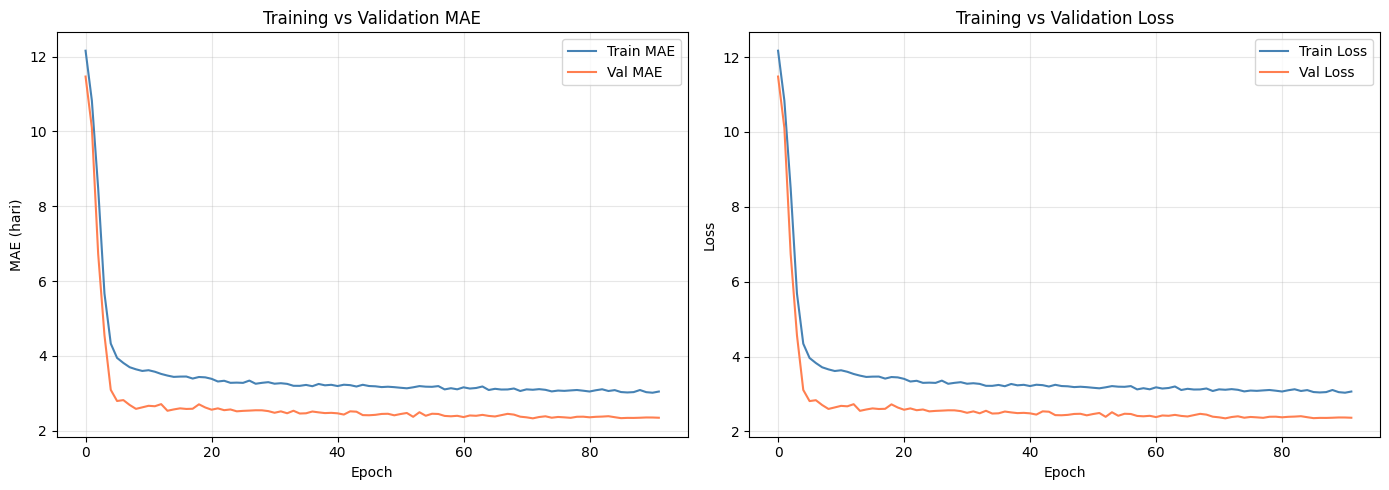

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE
axes[0].plot(history.history['mae'], label='Train MAE', color='steelblue')
axes[0].plot(history.history['val_mae'], label='Val MAE', color='coral')
axes[0].set_title('Training vs Validation MAE')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MAE (hari)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='coral')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Load model terbaik (dari checkpoint)
best_model = keras.models.load_model('model.keras')

# Prediksi (float)
y_pred_raw = best_model.predict(X_test, verbose=0).flatten()

# Pembulatan hanya untuk tampilan / inference — TIDAK dipakai untuk menghitung metrik
y_pred_rounded = np.clip(np.round(y_pred_raw), 0, None).astype(int)

# ── Metrik pada nilai float (lebih akurat) ──
mae  = mean_absolute_error(y_test, y_pred_rounded)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rounded))
r2   = r2_score(y_test, y_pred_rounded)

print('=' * 40)
print('  EVALUASI TEST SET')
print('=' * 40)
print(f'  MAE  : {mae:.3f} hari')
print(f'  RMSE : {rmse:.3f} hari')
print(f'  R²   : {r2:.4f}')
print('=' * 40)

# ── Perbandingan aktual vs prediksi ──
results_df = pd.DataFrame({
    'Aktual (hari)': y_test,
    'Prediksi': y_pred_rounded,
    'Error': np.abs(y_test - y_pred_rounded).round(2)
})
results_df.head(20)

  EVALUASI TEST SET
  MAE  : 2.536 hari
  RMSE : 3.659 hari
  R²   : 0.8794


,Aktual (hari),Prediksi,Error
0,3,3,0
1,38,22,16
2,13,12,1
3,21,14,7
4,7,9,2
5,5,4,1
6,3,2,1
7,10,9,1
8,0,1,1
9,8,16,8


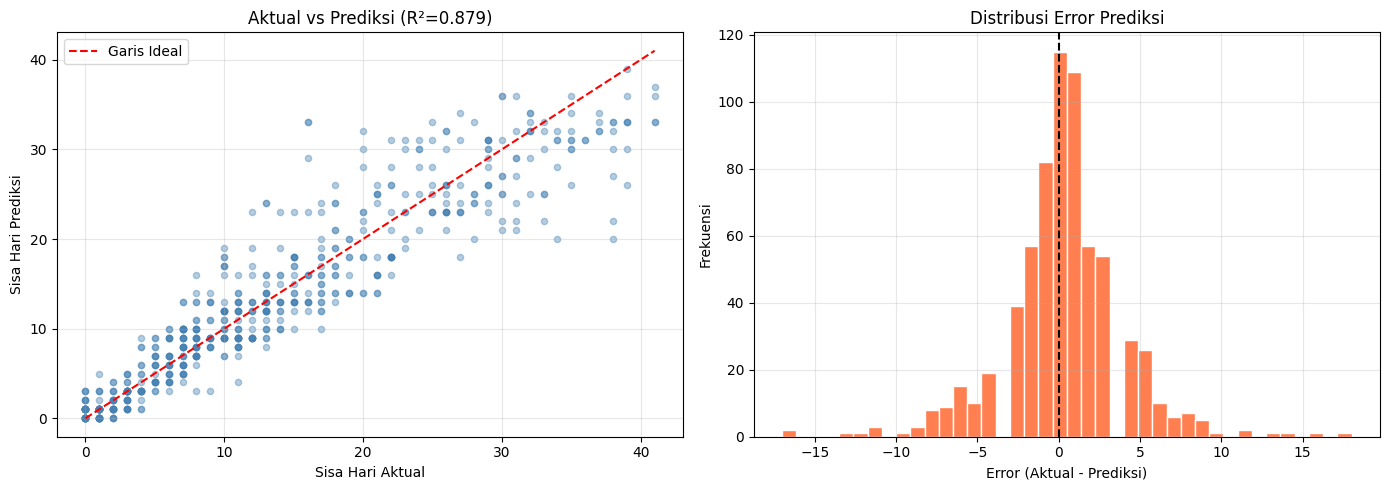

In [17]:
# ── Plot Aktual vs Prediksi ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(y_test, y_pred_rounded, alpha=0.4, color='steelblue', s=20)
max_val = max(y_test.max(), y_pred_rounded.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', label='Garis Ideal')
axes[0].set_xlabel('Sisa Hari Aktual')
axes[0].set_ylabel('Sisa Hari Prediksi')
axes[0].set_title(f'Aktual vs Prediksi (R²={r2:.3f})')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribusi error
errors = y_test - y_pred_rounded
axes[1].hist(errors, bins=40, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Error (Aktual - Prediksi)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Error Prediksi')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Simpan metadata

In [18]:
metadata = {
    "model_name": "MLP_SisaHari",
    "saved_at": datetime.now().isoformat(),
    "architecture": {
        "hidden_layers": [128, 64, 32],
        "activation": "relu",
        "dropout_rates": [0.3, 0.2, 0.1],
        "regularization": "L2(1e-4)",
        "output_activation": "linear"
    },
    "training": {
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "loss": "mae",
        "batch_size": 32,
        "max_epochs": 200,
        "early_stopping_patience": 20,
        "seed": SEED
    },
    "preprocessing": {
        "categorical_columns": CAT_COLS,
        "numerical_columns": NUM_COLS,
        "target_column": TARGET,
        "scaler": "StandardScaler",
        "encoder": "LabelEncoder"
    },
    "evaluation": {
        "mae": round(float(mae), 4),
        "rmse": round(float(rmse), 4),
        "r2": round(float(r2), 4)
    },
    "files": {
        "model": "model.keras",
        "metadata": "model_metadata.json"
    }
}

metadata_path = 'model_metadata.json'

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print(f"Metadata disimpan → {metadata_path}")
print(json.dumps(metadata, indent=4, ensure_ascii=False))

Metadata disimpan → model_metadata.json
{
    "model_name": "MLP_SisaHari",
    "saved_at": "2026-05-23T19:04:51.605671",
    "architecture": {
        "hidden_layers": [
            128,
            64,
            32
        ],
        "activation": "relu",
        "dropout_rates": [
            0.3,
            0.2,
            0.1
        ],
        "regularization": "L2(1e-4)",
        "output_activation": "linear"
    },
    "training": {
        "optimizer": "Adam",
        "learning_rate": 0.001,
        "loss": "mae",
        "batch_size": 32,
        "max_epochs": 200,
        "early_stopping_patience": 20,
        "seed": 42
    },
    "preprocessing": {
        "categorical_columns": [
            "nama_item",
            "jenis_item",
            "lokasi_penyimpanan",
            "label"
        ],
        "numerical_columns": [
            "hari_sejak_pembelian"
        ],
        "target_column": "sisa_hari",
        "scaler": "StandardScaler",
        "encoder": "LabelE